<a href="https://colab.research.google.com/github/Sourabhverma94/Machine-Learning/blob/main/Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving employee_salary_regression.csv to employee_salary_regression.csv


In [ ]:
import pandas as pd
df=pd.read_csv('employee_salary_regression.csv')
print(df.head())

  employee_id  age  years_experience education_level           job_role  \
0     EMP0001   29                 9          Master  Software Engineer   
1     EMP0002   27                 6        Bachelor        ML Engineer   
2     EMP0003   36                13          Master       Data Analyst   
3     EMP0004   43                23     High School             DevOps   
4     EMP0005   24                 1     High School             DevOps   

   city_tier  performance_score  num_skills  remote_work  annual_salary_usd  
0          1                2.4           3            0          106343.31  
1          3                2.1           5            1           82852.60  
2          1                4.1           7            1          142019.59  
3          1                3.1           7            1          159972.80  
4          1                3.7          12            1           94126.86  


In [ ]:
df.describe()

,age,years_experience,city_tier,performance_score,num_skills,remote_work,annual_salary_usd
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,40.668000,18.617000,2.046000,3.506200,7.161000,0.488000,137295.111970
std,11.536415,11.634848,0.826176,0.863775,3.103661,0.500106,34692.969621
min,22.000000,0.000000,1.000000,2.000000,2.000000,0.000000,66716.640000
25%,30.000000,8.000000,1.000000,2.800000,4.000000,0.000000,107616.092500
50%,41.000000,19.000000,2.000000,3.500000,7.000000,0.000000,137537.955000
75%,51.000000,29.000000,3.000000,4.300000,10.000000,1.000000,164807.105000
max,60.000000,40.000000,3.000000,5.000000,12.000000,1.000000,217067.540000


In [ ]:
df.columns

Index(['employee_id', 'age', 'years_experience', 'education_level', 'job_role',
       'city_tier', 'performance_score', 'num_skills', 'remote_work',
       'annual_salary_usd'],
      dtype='object')

In [ ]:
df.select_dtypes(include='object').columns

Index(['employee_id', 'education_level', 'job_role'], dtype='object')

In [ ]:
df.isnull().sum

<bound method DataFrame.sum of      employee_id    age  years_experience  education_level  job_role  \
0          False  False             False            False     False   
1          False  False             False            False     False   
2          False  False             False            False     False   
3          False  False             False            False     False   
4          False  False             False            False     False   
..           ...    ...               ...              ...       ...   
995        False  False             False            False     False   
996        False  False             False            False     False   
997        False  False             False            False     False   
998        False  False             False            False     False   
999        False  False             False            False     False   

     city_tier  performance_score  num_skills  remote_work  annual_salary_usd  
0        False              False       False        False              False  
1        False              False       False        False              False  
2        False              False       False        False              False  
3        False              False       False        False              False  
4        False              False       False        False              False  
..         ...                ...         ...          ...                ...  
995      False              False       False        False              False  
996      False              False       False        False              False  
997      False              False       False        False              False  
998      False              False       False        False              False  
999      False              False       False        False              False  

[1000 rows x 10 columns]>

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
for col in ['education_level','job_role','city_tier']:
  print(" _______________")
  print(df[col].value_counts())
  print()



 _______________
education_level
Bachelor       258
PhD            256
Master         246
High School    240
Name: count, dtype: int64

 _______________
job_role
DevOps               190
Data Analyst         178
Product Manager      168
QA Engineer          165
Software Engineer    152
ML Engineer          147
Name: count, dtype: int64

 _______________
city_tier
3    365
1    319
2    316
Name: count, dtype: int64



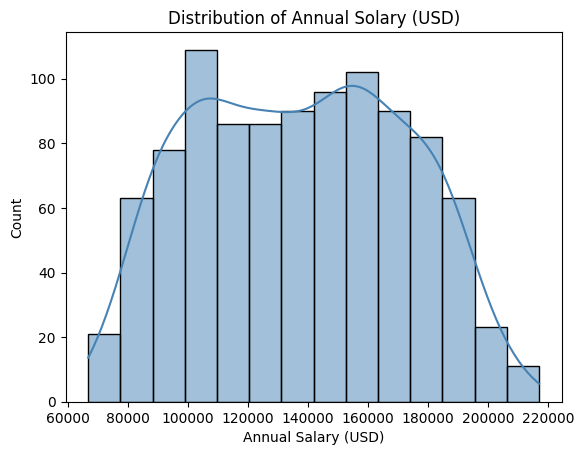

In [ ]:
import seaborn as sns

import matplotlib.pyplot as plt

sns.histplot(df['annual_salary_usd'], kde=True, color='steelblue')

plt.title('Distribution of Annual Solary (USD)')

plt.xlabel('Annual Salary (USD)')

plt.show()

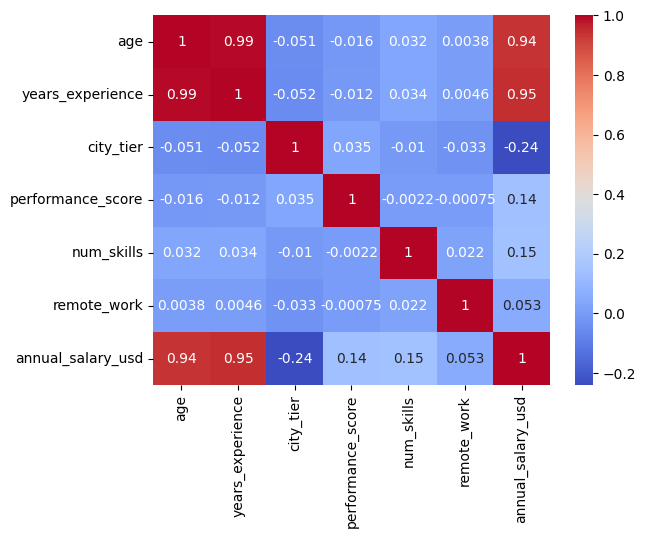

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

In [ ]:
df_encoded=pd.get_dummies(
    df.drop(columns='employee_id'),
    columns=['education_level','job_role'],
    drop_first=True

)
df_encoded.head()

,age,years_experience,city_tier,performance_score,num_skills,remote_work,annual_salary_usd,education_level_High School,education_level_Master,education_level_PhD,job_role_DevOps,job_role_ML Engineer,job_role_Product Manager,job_role_QA Engineer,job_role_Software Engineer
0,29,9,1,2.4,3,0,106343.31,False,True,False,False,False,False,False,True
1,27,6,3,2.1,5,1,82852.60,False,False,False,False,True,False,False,False
2,36,13,1,4.1,7,1,142019.59,False,True,False,False,False,False,False,False
3,43,23,1,3.1,7,1,159972.80,True,False,False,True,False,False,False,False
4,24,1,1,3.7,12,1,94126.86,True,False,False,True,False,False,False,False


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
x=df_encoded.drop(columns='annual_salary_usd')
y=df_encoded['annual_salary_usd']

x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=42)

print("Training set size:",x_train.shape)
print("Testing set size:",x_test.shape)

Training set size: (800, 14)
Testing set size: (200, 14)


In [ ]:
lr_model=LinearRegression()
lr_model.fit(x_train,y_train)

y_train_pred=lr_model.predict(x_train)
y_test_pred=lr_model.predict(x_test)

print("Model trained successfully.")

Model trained successfully.


In [ ]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

test_rmse=root_mean_squared_error(y_test,y_test_pred)
test_r2=r2_score(y_test,y_test_pred)
test_mae=mean_absolute_error(y_test,y_test_pred) # Calculate MAE for the test set

print("R^2",round(test_r2,4))
print("MAE:",round(test_mae,2))
print("RMSE:",round(test_rmse,2))

R^2 0.9854
MAE: 3524.83
RMSE: 4381.87


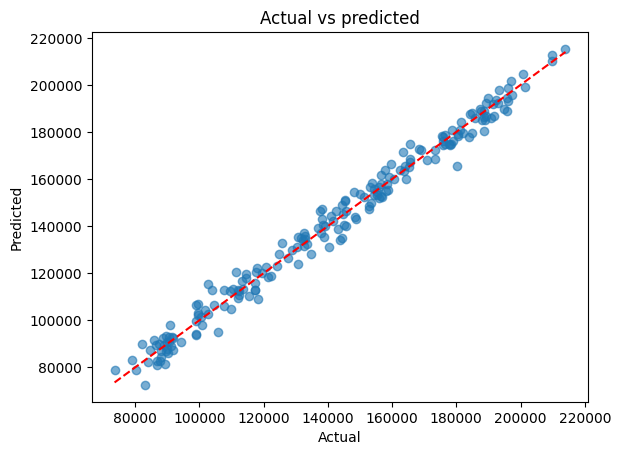

In [ ]:
plt.scatter(y_test,y_test_pred,alpha=0.6)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs predicted")
plt.show()
plt.show()

In [ ]:
import joblib
joblib.dump(lr_model,'salary_model.pkl')

['salary_model.pkl']